<a href="https://colab.research.google.com/github/krishshah8000/Deep-learning/blob/main/Experiment_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf

# Load the MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

Sample training images:


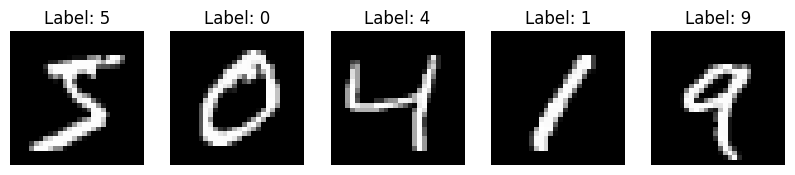


Sample testing images:


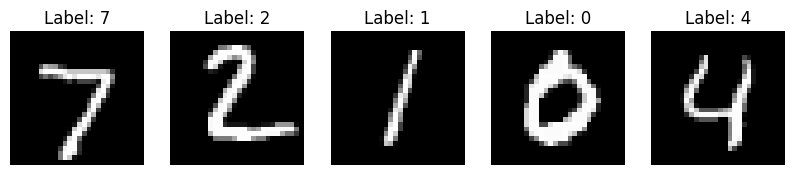

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Display a few training images and their labels
print("Sample training images:")
plt.figure(figsize=(10, 4))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.show()

# Display a few testing images and their labels
print("\nSample testing images:")
plt.figure(figsize=(10, 4))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(x_test[i], cmap='gray')
    plt.title(f"Label: {y_test[i]}")
    plt.axis('off')
plt.show()

In [ ]:
# Display the shapes of the loaded data
print(f"Shape of training images: {x_train.shape}")
print(f"Shape of training labels: {y_train.shape}")
print(f"Shape of testing images: {x_test.shape}")
print(f"Shape of testing labels: {y_test.shape}")

Shape of training images: (60000, 28, 28)
Shape of training labels: (60000,)
Shape of testing images: (10000, 28, 28)
Shape of testing labels: (10000,)


### 1. Normalize Input Data

We need to normalize the pixel values of the images from the range [0, 255] to [0, 1]. This helps in faster convergence during training. Also, for a dense neural network, we need to flatten the 28x28 images into a 1D array of 784 pixels.

In [ ]:
# Normalize images to the range [0, 1]
x_train_normalized = x_train.astype('float32') / 255.0
x_test_normalized = x_test.astype('float32') / 255.0

# Flatten the images for a dense neural network
x_train_flattened = x_train_normalized.reshape((x_train.shape[0], -1))
x_test_flattened = x_test_normalized.reshape((x_test.shape[0], -1))

print(f"Shape of normalized and flattened training images: {x_train_flattened.shape}")
print(f"Shape of normalized and flattened testing images: {x_test_flattened.shape}")

Shape of normalized and flattened training images: (60000, 784)
Shape of normalized and flattened testing images: (10000, 784)


### 2. Build Neural Network Model

Now, let's define a simple feed-forward neural network architecture. It will consist of an input layer, one hidden dense layer with ReLU activation, and an output dense layer with Softmax activation for classification.

In [ ]:
from tensorflow.keras import models, layers

def build_model():
    model = models.Sequential([
    layers.Dense(128, activation='relu', input_shape=(784,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
    ])
    return model

# Instantiate the model to verify its architecture
model_example = build_model()
model_example.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_14 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

### 3. Define Different Optimizers

We will define several optimizers from `tensorflow.keras.optimizers` to compare their performance during model training. Each optimizer will be instantiated with default learning rates (or commonly used ones if not specified).

In [ ]:
from tensorflow.keras import optimizers

# Define the optimizers
optimizers_dict = {
    'GradientDescent': optimizers.SGD(learning_rate=0.01), # Simple Gradient Descent
    'SGD_Momentum': optimizers.SGD(learning_rate=0.01, momentum=0.9), # SGD with Momentum
    'Adagrad': optimizers.Adagrad(learning_rate=0.01),
    'RMSprop': optimizers.RMSprop(learning_rate=0.001),
    'Adam': optimizers.Adam(learning_rate=0.001)
}

print("Optimizers defined successfully:")
for name, opt in optimizers_dict.items():
    print(f"- {name}: {type(opt).__name__}")

Optimizers defined successfully:
- GradientDescent: SGD
- SGD_Momentum: SGD
- Adagrad: Adagrad
- RMSprop: RMSprop
- Adam: Adam


### 4. Train Model Using Each Optimizer

Now, we will compile and train separate instances of our model using each of the defined optimizers. We'll store the training history (loss and accuracy) for each optimizer.

In [ ]:
history_dict = {}
epochs = 100 # You can adjust the number of epochs

for name, optimizer in optimizers_dict.items():
    print(f"\nTraining model with {name} optimizer...")
    model = build_model() # Get a fresh model for each optimizer
    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        x_train_flattened, y_train,
        epochs=epochs,
        validation_data=(x_test_flattened, y_test),



        verbose=0 # Set to 1 for progress bar
    )
    history_dict[name] = history


Training model with GradientDescent optimizer...

Training model with SGD_Momentum optimizer...

Training model with Adagrad optimizer...

Training model with RMSprop optimizer...

Training model with Adam optimizer...


### 5. Record Loss and Accuracy & 6. Compare Performance

Let's visualize and compare the training and validation loss and accuracy for each optimizer.

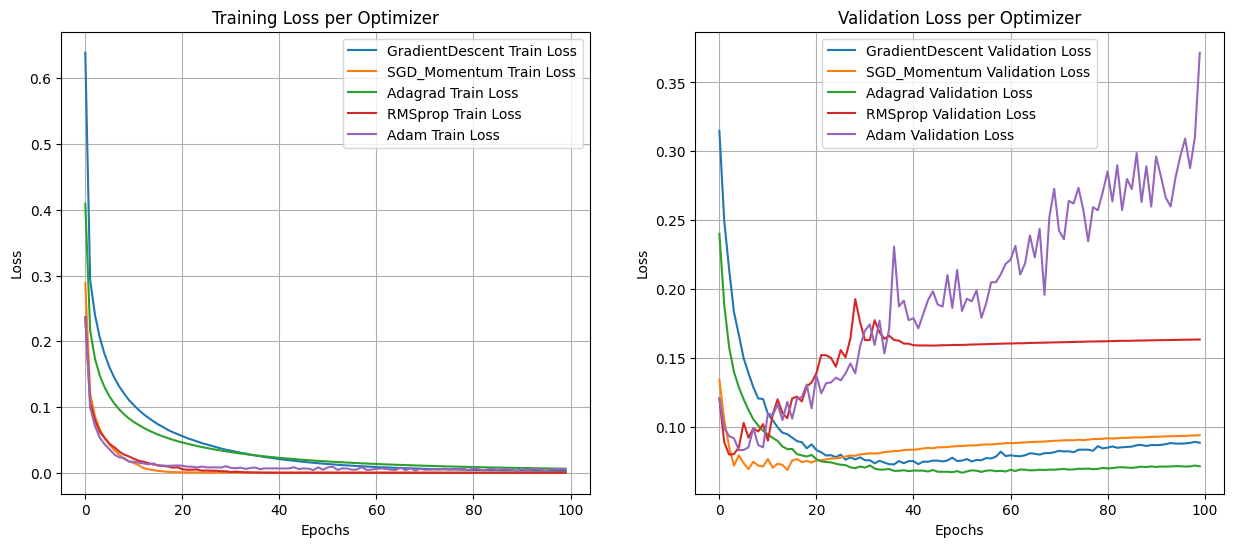

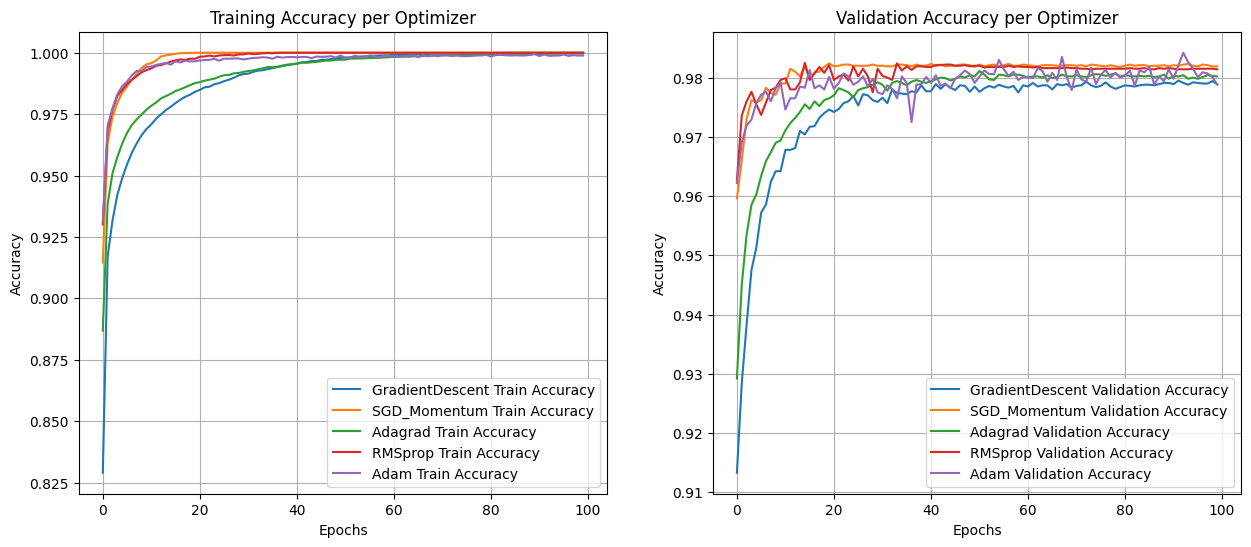

In [ ]:
plt.figure(figsize=(15, 6))

# Plot Training Loss
plt.subplot(1, 2, 1)
for name, history in history_dict.items():
    plt.plot(history.history['loss'], label=f'{name} Train Loss')
plt.title('Training Loss per Optimizer')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot Validation Loss
plt.subplot(1, 2, 2)
for name, history in history_dict.items():
    plt.plot(history.history['val_loss'], label=f'{name} Validation Loss')
plt.title('Validation Loss per Optimizer')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(15, 6))

# Plot Training Accuracy
plt.subplot(1, 2, 1)
for name, history in history_dict.items():
    plt.plot(history.history['accuracy'], label=f'{name} Train Accuracy')
plt.title('Training Accuracy per Optimizer')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot Validation Accuracy
plt.subplot(1, 2, 2)
for name, history in history_dict.items():
    plt.plot(history.history['val_accuracy'], label=f'{name} Validation Accuracy')
plt.title('Validation Accuracy per Optimizer')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
best_optimizer = None
best_accuracy = 0

print("Optimizer Performance Summary:")
for name, history in history_dict.items():
    final_val_accuracy = history.history['val_accuracy'][-1]
    print(f"- {name}: Final Validation Accuracy = {final_val_accuracy:.4f}")
    if final_val_accuracy > best_accuracy:
        best_accuracy = final_val_accuracy
        best_optimizer = name

learning_rate_info = "N/A"
if best_optimizer and best_optimizer in optimizers_dict:
    # Attempt to get learning rate, may vary by optimizer type
    optimizer_instance = optimizers_dict[best_optimizer]
    if hasattr(optimizer_instance, 'learning_rate'):
        # For optimizers like Adam, Adagrad, RMSprop, SGD
        if hasattr(optimizer_instance.learning_rate, 'numpy'):
             learning_rate_info = f"{optimizer_instance.learning_rate.numpy():.4f}"
        else:
            learning_rate_info = f"{optimizer_instance.learning_rate:.4f}"
    elif hasattr(optimizer_instance, '_learning_rate'): # for older tf versions
        learning_rate_info = f"{optimizer_instance._learning_rate.numpy():.4f}"

print(f"\nBased on final validation accuracy, the best performing optimizer is: {best_optimizer}")
print(f"Its final validation accuracy is: {best_accuracy:.4f}")
print(f"Its configured learning rate is: {learning_rate_info}")

Optimizer Performance Summary:
- GradientDescent: Final Validation Accuracy = 0.9789
- SGD_Momentum: Final Validation Accuracy = 0.9819
- Adagrad: Final Validation Accuracy = 0.9802
- RMSprop: Final Validation Accuracy = 0.9814
- Adam: Final Validation Accuracy = 0.9788

Based on final validation accuracy, the best performing optimizer is: SGD_Momentum
Its final validation accuracy is: 0.9819
Its configured learning rate is: 0.0100


### 7. Make Predictions using the Best Model

Let's use the model trained with the best performing optimizer (`SGD_Momentum`) to make predictions on a few test samples and visualize the results.

Re-training model with the best optimizer: SGD_Momentum...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model trained with best optimizer for prediction.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step


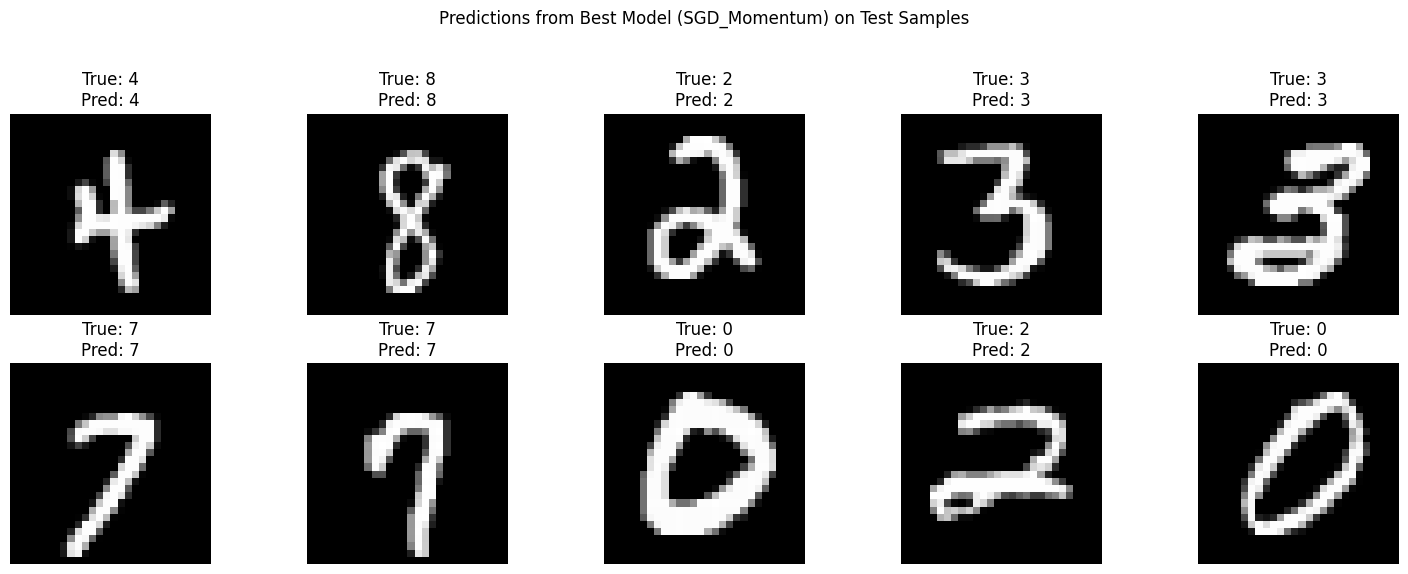

In [ ]:
# Retrieve the model trained with the best optimizer (SGD_Momentum)
# We need to rebuild and train the model one last time to get the actual model object,
# as history_dict only stores the history, not the model itself.
# Alternatively, we could save the best model during the training loop.

# For simplicity, let's re-instantiate and train the best model again
# This assumes 'SGD_Momentum' was indeed the best and we want to use its configuration

print(f"Re-training model with the best optimizer: {best_optimizer}...")
best_model = build_model()

# Get the original optimizer instance and its parameters to create a *new* instance
original_optimizer = optimizers_dict[best_optimizer]

# Explicitly cast learning rate to a standard Python float
lr_value = float(original_optimizer.learning_rate.numpy() if hasattr(original_optimizer.learning_rate, 'numpy') else original_optimizer.learning_rate)

# Create a new optimizer instance based on the best_optimizer's type and parameters
if best_optimizer == 'GradientDescent':
    best_optimizer_instance = optimizers.SGD(learning_rate=lr_value)
elif best_optimizer == 'SGD_Momentum':
    momentum_value = float(original_optimizer.momentum.numpy() if hasattr(original_optimizer.momentum, 'numpy') else original_optimizer.momentum)
    best_optimizer_instance = optimizers.SGD(learning_rate=lr_value, momentum=momentum_value)
elif best_optimizer == 'Adagrad':
    best_optimizer_instance = optimizers.Adagrad(learning_rate=lr_value)
elif best_optimizer == 'RMSprop':
    best_optimizer_instance = optimizers.RMSprop(learning_rate=lr_value)
elif best_optimizer == 'Adam':
    best_optimizer_instance = optimizers.Adam(learning_rate=lr_value)
else:
    raise ValueError(f"Optimizer {best_optimizer} not recognized for re-instantiation.")

best_model.compile(
    optimizer=best_optimizer_instance,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train for the same number of epochs used for comparison
best_model.fit(
    x_train_flattened, y_train,
    epochs=epochs,
    validation_data=(x_test_flattened, y_test),
    verbose=0 # Set to 1 for progress bar
)

print("Model trained with best optimizer for prediction.")

# Select a few test samples for prediction
num_samples_to_predict = 10
sample_indices = np.random.choice(len(x_test_flattened), num_samples_to_predict, replace=False)

sample_images = x_test[sample_indices] # Original images for display
sample_data = x_test_flattened[sample_indices]
sample_labels = y_test[sample_indices]

# Make predictions
predictions = best_model.predict(sample_data)
predicted_labels = np.argmax(predictions, axis=1)

# Visualize predictions
plt.figure(figsize=(15, 6))
for i in range(num_samples_to_predict):
    plt.subplot(2, 5, i + 1)
    plt.imshow(sample_images[i], cmap='gray')
    plt.title(f"True: {sample_labels[i]}\nPred: {predicted_labels[i]}")
    plt.axis('off')
plt.suptitle('Predictions from Best Model (SGD_Momentum) on Test Samples')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()